In [2]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

In [3]:
import pickle, os

with open('data/data_churn_final.pkl', 'rb') as f:
    X_treino, X_teste, y_treino, y_teste = pickle.load(f)

In [4]:
RandomForest = RandomForestClassifier()
RandomForest.fit(X_treino, y_treino)
y_pred_rf = RandomForest.predict(X_teste)
accuracy_score(y_teste,y_pred_rf)


0.7803837953091685

In [5]:
svm = SVC()
svm.fit(X_treino, y_treino)
y_pred_svm = svm.predict(X_teste)
accuracy_score(y_teste,y_pred_svm)

0.783226723525231

In [6]:
rede_neural = MLPClassifier( hidden_layer_sizes=(100, 50), activation = 'relu', solver='adam', max_iter=1000)
rede_neural.fit(X_treino, y_treino)
y_pred_MLP = rede_neural.predict(X_teste)
accuracy_score(y_teste,y_pred_MLP)

0.757640369580668

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_treino, y_treino)
y_pred_knn = knn.predict(X_teste)
accuracy_score(y_teste,y_pred_knn)


0.7469793887704336

In [8]:
log_regression = LogisticRegression()
log_regression.fit(X_treino, y_treino)
y_pred_log = log_regression.predict(X_teste)
accuracy_score(y_teste,y_pred_log)


0.7889125799573561

In [9]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_treino, y_treino)
y_pred_nb = naive_bayes.predict(X_teste)
accuracy_score(y_teste,y_pred_nb)

0.6837242359630419

#Tuning de parametros

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
X_churn = np.concatenate((X_treino, X_teste), axis=0)
y_churn = np.concatenate((y_treino, y_teste), axis=0)

X_churn.shape, y_churn.shape

((7032, 45), (7032,))

Random Forest

In [12]:
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [13]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)


Melhores Parâmetros: {'criterion': 'gini', 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 150}
Melhor Resultado: 0.8033281064702903


SVM

In [14]:
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

In [15]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)

Melhores Parâmetros: {'C': 2.0, 'kernel': 'linear', 'tol': 0.001}
Melhor Resultado: 0.7990632086468693


Rede Neural

In [16]:
parametros = {'activation': ['relu', 'logistic', 'tahn'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56]}

In [17]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)

c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\sit

Melhores Parâmetros: {'activation': 'logistic', 'batch_size': 10, 'solver': 'sgd'}
Melhor Resultado: 0.8004840661557079


KNN

In [18]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

In [19]:
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)

Melhores Parâmetros: {'n_neighbors': 20, 'p': 1}
Melhor Resultado: 0.7827077779159476


Regressão Logistica

In [20]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}

In [21]:
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

{'C': 2.0, 'solver': 'saga', 'tol': 0.0001}
0.8044654799564462


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [22]:
from sklearn.model_selection import cross_val_score, KFold

In [23]:
resultados_arvore = []
resultados_random_forest = []
resultados_knn = []
resultados_logistica = []
resultados_svm = []
resultados_rede_neural = []

for i in range(30):

    print(i)
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    random_forest = RandomForestClassifier(criterion = 'entropy', min_samples_leaf = 10, min_samples_split = 2, n_estimators= 40)
    scores_rf = cross_val_score(random_forest, X_churn, y_churn, cv=kfold)
    resultados_random_forest.append(scores_rf.mean())

    svm = SVC(C=2.0, kernel='linear', tol=0.001)
    scores_svm = cross_val_score(svm, X_churn, y_churn, cv=kfold)
    resultados_svm.append(scores_svm.mean())

    rede_neural = MLPClassifier(activation='logistic', batch_size=56, solver='sgd')
    scores_rede_neural = cross_val_score(rede_neural, X_churn, y_churn, cv=kfold)
    resultados_rede_neural.append(scores_rede_neural.mean())

    knn = KNeighborsClassifier(n_neighbors=20, p=1)
    scores_knn = cross_val_score(knn, X_churn, y_churn, cv=kfold)
    resultados_knn.append(scores_knn.mean())

    logistica = LogisticRegression(C=2.0, solver='saga', tol=0.0001)
    scores_logistica = cross_val_score(logistica, X_churn, y_churn, cv=kfold)
    resultados_logistica.append(scores_logistica.mean())

    



0


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

1


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

2


...

c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

28


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

29


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

In [24]:
resultados = pd.DataFrame({
    'Random Forest': resultados_random_forest,
    'SVM': resultados_svm,
    'Rede Neural': resultados_rede_neural,
    'KNN': resultados_knn,
    'Logística': resultados_logistica})

In [25]:
resultados.describe()

,Random Forest,SVM,Rede Neural,KNN,Logística
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.801925,0.799085,0.801441,0.783414,0.804124
std,0.002116,0.000499,0.000894,0.001745,0.000851
min,0.797498,0.798209,0.799347,0.780580,0.802473
25%,0.800378,0.798776,0.800837,0.782178,0.803295
50%,0.801834,0.799065,0.801479,0.783274,0.804466
75%,0.802908,0.799344,0.801872,0.784591,0.804751
max,0.807736,0.800480,0.803468,0.787259,0.805460


In [26]:
resultados.var()

Random Forest    4.478901e-06
SVM              2.491799e-07
Rede Neural      7.989086e-07
KNN              3.045482e-06
Logística        7.248319e-07
dtype: float64

In [27]:
(resultados.std() / resultados.mean()) * 100

Random Forest    0.263908
SVM              0.062469
Rede Neural      0.111526
KNN              0.222760
Logística        0.105876
dtype: float64

In [28]:
alpha = 0.05
from scipy.stats import shapiro

In [29]:
shapiro(resultados_random_forest), shapiro(resultados_svm), shapiro(resultados_rede_neural), shapiro(resultados_knn), shapiro(resultados_logistica)

(ShapiroResult(statistic=np.float64(0.9764205974833415), pvalue=np.float64(0.7245160370343047)),
 ShapiroResult(statistic=np.float64(0.9672902597929622), pvalue=np.float64(0.4679392567724623)),
 ShapiroResult(statistic=np.float64(0.9774039996321053), pvalue=np.float64(0.7531375162523049)),
 ShapiroResult(statistic=np.float64(0.9691497445512587), pvalue=np.float64(0.5161797812279992)),
 ShapiroResult(statistic=np.float64(0.9025756664614629), pvalue=np.float64(0.009715421100317041)))

In [32]:
import seaborn as sns

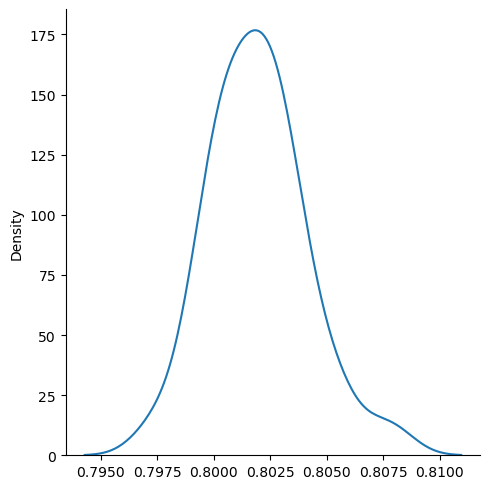

In [34]:
sns.displot(resultados_random_forest, kind = 'kde')

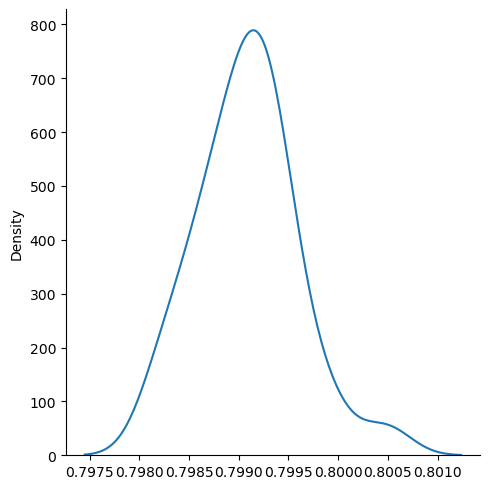

In [35]:
sns.displot(resultados_svm, kind = 'kde')

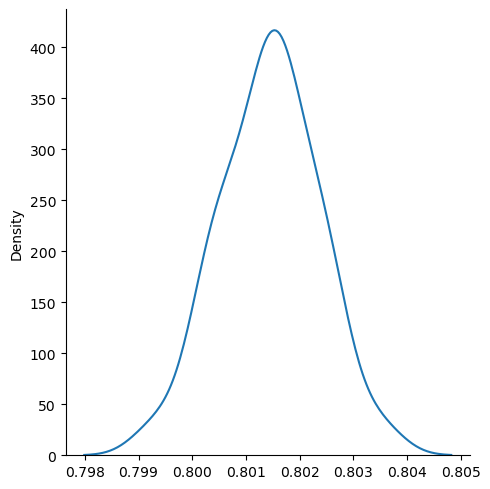

In [36]:
sns.displot(resultados_rede_neural, kind = 'kde')

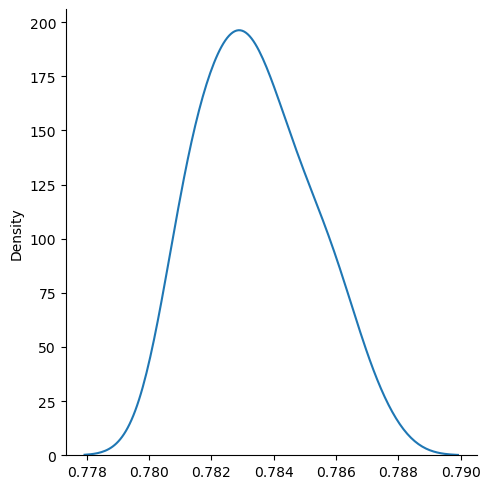

In [37]:
sns.displot(resultados_knn, kind = 'kde')

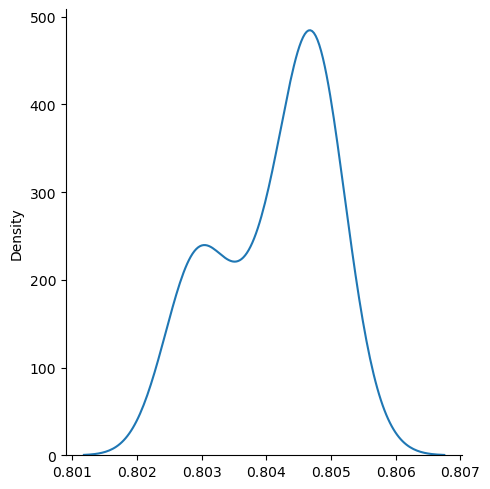

In [38]:
sns.displot(resultados_logistica, kind = 'kde')